In [1]:
from pathlib import Path
import yaml
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import os

In [2]:
# # get path to project root directory
# project_root = Path.cwd().parents[0]

# # build path to yaml config file
# config_path = project_root / "configs"/"paths.yaml"

In [3]:
# with open(config_path) as f:
#     paths = yaml.safe_load(f)
# paths

In [4]:
# # Access imagery root directory
# imagery_root = project_root / paths["imagery"]["nakivale_sample"]

# # sample grid cell
# grid_cell_id = 357

# # Access grid cell 208 folder
# chip_dir = imagery_root / f'{grid_cell_id}'

# print(chip_dir)

In [5]:
import re
import xml.etree.ElementTree as ET
from pathlib import Path

def parse_maxar_metadata(chip_dir: Path):
    """
    Parse Maxar XML or IMD metadata.
    Returns a dict with keys: cloud_cover, sun_elevation, sun_azimuth, acquisition_date, satellite, etc.
    """

    xml_files = list(chip_dir.glob("*.XML"))
    imd_files = list(chip_dir.glob("*.IMD"))

    meta = {}

    # ---- XML metadata (preferred) ----
    if xml_files:
        xml = xml_files[0]
        tree = ET.parse(xml)
        root = tree.getroot()

        # Cloud cover (0–100)
        cc = root.find(".//CLOUD_COVER")
        if cc is not None:
            meta["cloud_cover"] = float(cc.text)

        # Sun angles
        se = root.find(".//SUN_ELEVATION")
        if se is not None:
            meta["sun_elevation"] = float(se.text)

        sa = root.find(".//SUN_AZIMUTH")
        if sa is not None:
            meta["sun_azimuth"] = float(sa.text)

        # Satellite
        sat = root.find(".//SATID")
        if sat is not None:
            meta["satellite"] = sat.text

    # ---- IMD fallback ----
    if imd_files and "cloud_cover" not in meta:
        # IMD cloud cover e.g. "CLOUDCOVER = 005"
        text = imd_files[0].read_text()
        m = re.search(r"CLOUDCVR=(\d+)", text)
        if m:
            meta["cloud_cover"] = int(m.group(1))

    return meta

In [6]:
import numpy as np
import rasterio

def compute_cloud_shadow_mask(chip_path, cloud_thresh=0.15, shadow_thresh=0.10):
    """
    Compute cloud and shadow mask for an 8-band WV02/WV03 chip.
    cloud_thresh and shadow_thresh are fractions of reflectance (0-1 after scaling).
    Returns: cloud_mask, shadow_mask, combined_mask, scaled_rgb
    """
    with rasterio.open(chip_path) as src:
        img = src.read()  # (bands, h, w)

    # Convert 11-bit DN values → reflectance-scale [0..1]
    img_f = img.astype("float32") / 2047.0

    coastal, blue, green, yellow, red, rededge, nir1, nir2 = img_f

    # ---- Cloud detection ----
    # Clouds = bright in visible (B,G,R) AND low NIR
    brightness = (blue + green + red) / 3

    cloud_mask = (brightness > cloud_thresh) & (nir1 < 0.25)

    # ---- Shadow detection ----
    # Shadows = very dark in all bands + especially dark in NIR
    dark_all = (img_f < shadow_thresh).all(axis=0)
    dark_nir = nir1 < (shadow_thresh * 0.7)

    shadow_mask = dark_all & dark_nir

    # Combined mask
    combined = cloud_mask | shadow_mask

    # Create RGB for visualization
    rgb = np.dstack([red, green, blue])
    p2, p98 = np.percentile(rgb[rgb > 0], (2, 98))
    rgb_stretch = np.clip((rgb - p2) / (p98 - p2), 0, 1)

    return cloud_mask, shadow_mask, combined, rgb_stretch


In [7]:
def save_clean_chip(chip_path, out_path, combined_mask):
    """ Save chip with clouds/shadows set to 0. """
    with rasterio.open(chip_path) as src:
        profile = src.profile
        img = src.read()

    img_clean = img.copy()
    for b in range(img.shape[0]):
        band = img_clean[b]
        band[combined_mask] = 0
        img_clean[b] = band

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(img_clean)

    print(f"✓ Saved clean chip → {out_path}")

In [8]:
import matplotlib.pyplot as plt

def show_mask(rgb, cloud_mask, shadow_mask):
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.title("RGB")
    plt.imshow(rgb)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Cloud Mask")
    plt.imshow(cloud_mask, cmap="Reds")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Shadow Mask")
    plt.imshow(shadow_mask, cmap="Purples")
    plt.axis("off")

    plt.show()


Metadata: {'satellite': 'WV02'}


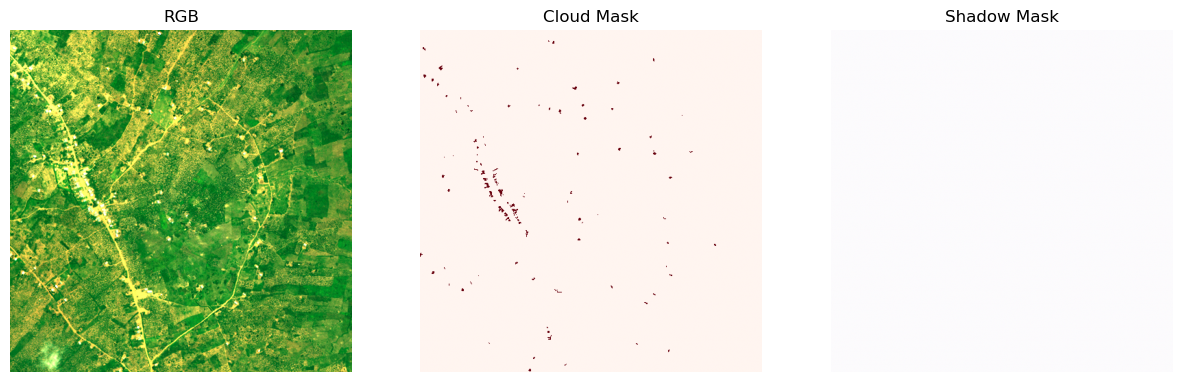

✓ Saved clean chip → C:\Users\Zachary\phd_classes\uganda\data\imagery\nakivale_sample\357\357_15JUN15083001-M2AS-507744471100_01_P001_CLEAN.tif


In [10]:
from pathlib import Path

chip_dir = Path(r"C:\\Users\\Zachary\\phd_classes\\uganda\\data\\imagery\\nakivale_sample\\357")
chip_path = chip_dir / "357_15JUN15083001-M2AS-507744471100_01_P001.tif"

# Parse metadata
meta = parse_maxar_metadata(chip_dir)
print("Metadata:", meta)

# Compute masks
cloud_mask, shadow_mask, combined_mask, rgb = compute_cloud_shadow_mask(chip_path)

# Visualize
show_mask(rgb, cloud_mask, shadow_mask)

# Save clean version
out_clean = chip_dir / f"{chip_path.stem}_CLEAN.tif"
save_clean_chip(chip_path, out_clean, combined_mask)
